# California Housing: Decision Tree Regression and Model Complexity

## Project Overview

This notebook applies decision-tree regression to the California Housing dataset and extends the baseline model through depth tuning, train/test error analysis, random splitting, prediction averaging, and a Random Forest comparison.

### Technical Coverage

- DecisionTreeRegressor
- Tree depth and leaf count
- Mean squared error
- Tree visualization
- Maximum-depth search
- Training vs. test error
- Random splitters
- Repeated-run average error
- Averaging predictions across randomized trees
- Averaging repeated best-split predictions
- RandomForestRegressor comparison

## 1. California Housing Baseline

The California Housing dataset is split into training and test subsets using a fixed split. An unrestricted regression tree establishes the baseline model size and test error.

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree

dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)
print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
pred = model.predict(X_test)

print(f'mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

Model size: depth = 35 number of leaves = 15884
mean_squared_error: 0.532600


## 2. Small Trees for Interpretation

A depth-3 tree provides a compact model that can be visualized directly.

In [5]:
model = DecisionTreeRegressor(max_depth = 3)
model.fit(X_train, y_train)
print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
pred = model.predict(X_test)

print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')

Model size: depth = 3 number of leaves = 8
mean_squared_error: 0.6331


### Depth-3 Tree Visualization

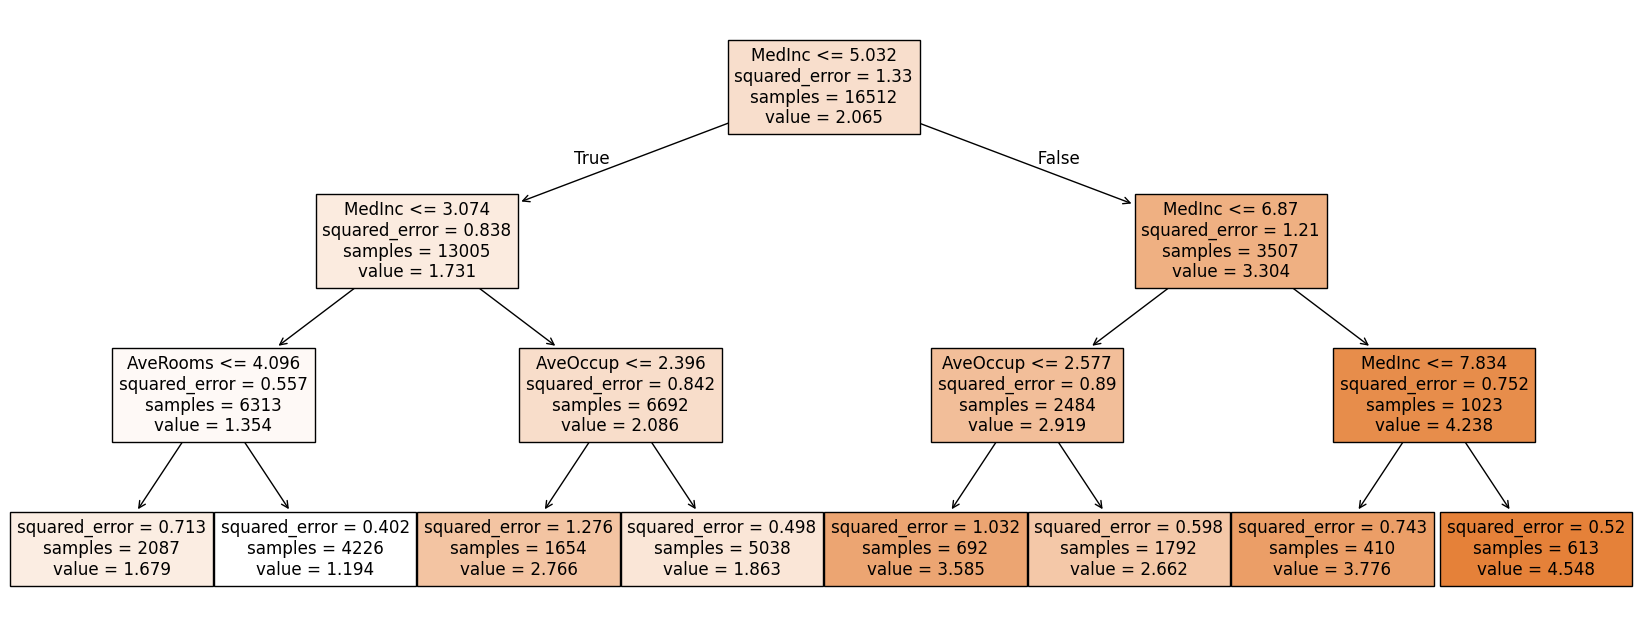

In [6]:
fig, ax = plt.subplots(figsize=(21,8))
t = tree.plot_tree(model, feature_names=dataset.feature_names,label='all',filled=True)

### Depth-4 Tree

Increasing the depth from 3 to 4 doubles the maximum number of terminal regions and reduces the saved test MSE.

Model size: depth = 4 number of leaves = 16
mean_squared_error: 0.5788


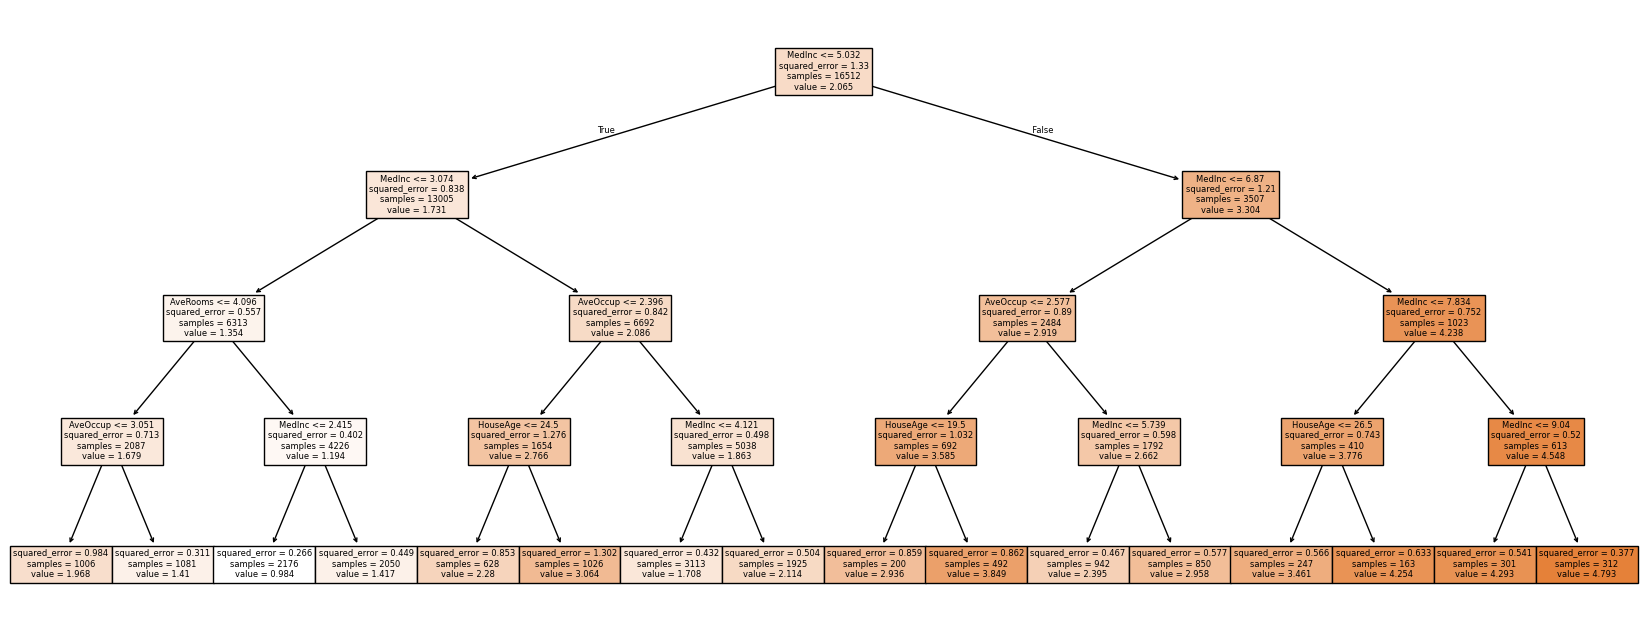

In [7]:
model = DecisionTreeRegressor(max_depth = 4)
model.fit(X_train, y_train)
print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
pred = model.predict(X_test)

print(f'mean_squared_error: {mean_squared_error(y_test,pred):6.4f}')

fig, ax = plt.subplots(figsize=(21,8))
t = tree.plot_tree(model, feature_names=dataset.feature_names,label='all',filled=True)

## 3. Selecting the Maximum Depth

Maximum depths from 1 through 39 are evaluated directly. The model with the smallest test MSE is retained as the best depth in the saved search.

In [8]:
min_err = np.inf
best_depth = -1
for max_depth in range(1,40):
  model = DecisionTreeRegressor(max_depth = max_depth)
  model.fit(X_train, y_train)
  print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test,pred)
  print(f'mean_squared_error: {mse:8.6f}')
  if mse < min_err:
    min_err = mse
    best_depth = max_depth

print(f'Best max_depth value {best_depth}, mean_squared_error: {min_err:8.6f}')


Model size: depth = 1 number of leaves = 2
mean_squared_error: 0.928355
Model size: depth = 2 number of leaves = 4
mean_squared_error: 0.741945
Model size: depth = 3 number of leaves = 8
mean_squared_error: 0.633110
Model size: depth = 4 number of leaves = 16
mean_squared_error: 0.578763
Model size: depth = 5 number of leaves = 32
mean_squared_error: 0.526278
Model size: depth = 6 number of leaves = 64
mean_squared_error: 0.486841
Model size: depth = 7 number of leaves = 126
mean_squared_error: 0.455495
Model size: depth = 8 number of leaves = 245
mean_squared_error: 0.427921
Model size: depth = 9 number of leaves = 452
mean_squared_error: 0.421186
Model size: depth = 10 number of leaves = 796
mean_squared_error: 0.429819
Model size: depth = 11 number of leaves = 1322
mean_squared_error: 0.432106
Model size: depth = 12 number of leaves = 2045
mean_squared_error: 0.455895
Model size: depth = 13 number of leaves = 2968
mean_squared_error: 0.474968
Model size: depth = 14 number of leaves 

The saved search identifies **`max_depth=9`** with a test MSE of **0.423657**.

## 4. Training and Test Error Across Depth

Training and test MSE are recorded for depths 1 through 35. This provides a direct view of the bias-variance tradeoff as the tree becomes more complex.

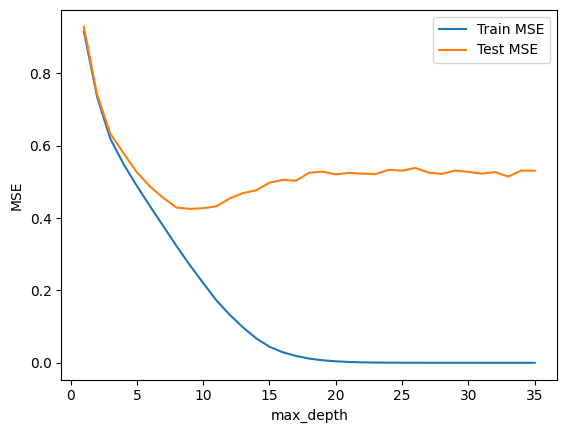

In [9]:
err_trn = []
err_tst = []
depths = np.arange(1,36)

for max_depth in depths:
  model = DecisionTreeRegressor(max_depth = max_depth)
  model.fit(X_train, y_train)
  #print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
  pred = model.predict(X_train)
  mse = mean_squared_error(y_train,pred)
  err_trn.append(mse)
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test,pred)
  err_tst.append(mse)

plt.figure()
plt.plot(depths,err_trn,label='Train MSE')
plt.plot(depths,err_tst,label='Test MSE')
plt.xlabel('max_depth')
plt.ylabel('MSE')
plt.legend()
plt.show()

The training error decreases as tree depth grows, while the test error reaches its minimum earlier and then begins to rise, demonstrating overfitting in regression trees.

## 5. Random Splitter Across 30 Runs

A regression tree using `splitter='random'` is fitted 30 times. Because random splitting produces a different tree from run to run, the MSE values are averaged across the 30 models.

In [10]:
sum_err = 0
n_tests = 30
model = DecisionTreeRegressor(splitter='random')

for i in range(n_tests):
  model.fit(X_train, y_train)
  print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test,pred)
  print(f'mean_squared_error: {mse:8.6f}')
  sum_err += mse

print(f'Average mean_squared_error: {sum_err/n_tests:8.6f}')

Model size: depth = 41 number of leaves = 16046
mean_squared_error: 0.514153
Model size: depth = 35 number of leaves = 16087
mean_squared_error: 0.551706
Model size: depth = 40 number of leaves = 16094
mean_squared_error: 0.644997
Model size: depth = 36 number of leaves = 16066
mean_squared_error: 0.532966
Model size: depth = 39 number of leaves = 16073
mean_squared_error: 0.618110
Model size: depth = 38 number of leaves = 16070
mean_squared_error: 0.634499
Model size: depth = 39 number of leaves = 16075
mean_squared_error: 0.615794
Model size: depth = 35 number of leaves = 16058
mean_squared_error: 0.594377
Model size: depth = 37 number of leaves = 16066
mean_squared_error: 0.561090
Model size: depth = 41 number of leaves = 16067
mean_squared_error: 0.635332
Model size: depth = 36 number of leaves = 16055
mean_squared_error: 0.613461
Model size: depth = 41 number of leaves = 16086
mean_squared_error: 0.549784
Model size: depth = 37 number of leaves = 16079
mean_squared_error: 0.601193

The saved average MSE across the 30 randomized trees is **0.604320**.

## 6. Averaging Predictions from Randomized Trees

Instead of averaging the individual model errors, this experiment averages the 30 prediction vectors first and then evaluates the MSE of the aggregated prediction.

In [11]:
sum_pred = 0
n_tests = 30
model = DecisionTreeRegressor(splitter='random')

for i in range(n_tests):
  model.fit(X_train, y_train)
  print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test,pred)
  print(f'mean_squared_error: {mse:8.6f}')
  sum_pred += pred

pred = sum_pred/n_tests
print(f'Mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

Model size: depth = 39 number of leaves = 16070
mean_squared_error: 0.584481
Model size: depth = 38 number of leaves = 16049
mean_squared_error: 0.591371
Model size: depth = 42 number of leaves = 16059
mean_squared_error: 0.631617
Model size: depth = 38 number of leaves = 16042
mean_squared_error: 0.581788
Model size: depth = 37 number of leaves = 16085
mean_squared_error: 0.597427
Model size: depth = 41 number of leaves = 16050
mean_squared_error: 0.518404
Model size: depth = 36 number of leaves = 16076
mean_squared_error: 0.538300
Model size: depth = 37 number of leaves = 16073
mean_squared_error: 0.623948
Model size: depth = 40 number of leaves = 16046
mean_squared_error: 0.646286
Model size: depth = 41 number of leaves = 16049
mean_squared_error: 0.512094
Model size: depth = 37 number of leaves = 16071
mean_squared_error: 0.602192
Model size: depth = 37 number of leaves = 16061
mean_squared_error: 0.467794
Model size: depth = 41 number of leaves = 16067
mean_squared_error: 0.517671

The saved MSE of the averaged randomized-tree prediction is **0.266055**, substantially lower than the average MSE of the individual randomized trees.

## 7. Averaging Repeated Best-Split Trees

A second prediction-averaging experiment uses depth-30 trees with `splitter='best'`. Thirty prediction vectors are averaged before computing the final MSE.

In [12]:
sum_pred = 0
n_tests = 30
model = DecisionTreeRegressor(max_depth = 30, splitter='best')

for i in range(n_tests):
  model.fit(X_train, y_train)
  print(f'Model size: depth = {model.get_depth()} number of leaves = {model.get_n_leaves()}')
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test,pred)
  print(f'mean_squared_error: {mse:8.6f}')
  sum_pred += pred

pred = sum_pred/n_tests
print(f'Mean_squared_error: {mean_squared_error(y_test,pred):8.6f}')

Model size: depth = 30 number of leaves = 15839
mean_squared_error: 0.530770
Model size: depth = 30 number of leaves = 15833
mean_squared_error: 0.525778
Model size: depth = 30 number of leaves = 15837
mean_squared_error: 0.526726
Model size: depth = 30 number of leaves = 15841
mean_squared_error: 0.541360
Model size: depth = 30 number of leaves = 15836
mean_squared_error: 0.533014
Model size: depth = 30 number of leaves = 15833
mean_squared_error: 0.538765
Model size: depth = 30 number of leaves = 15840
mean_squared_error: 0.527991
Model size: depth = 30 number of leaves = 15838
mean_squared_error: 0.534481
Model size: depth = 30 number of leaves = 15836
mean_squared_error: 0.523299
Model size: depth = 30 number of leaves = 15843
mean_squared_error: 0.526610
Model size: depth = 30 number of leaves = 15834
mean_squared_error: 0.517675
Model size: depth = 30 number of leaves = 15841
mean_squared_error: 0.533593
Model size: depth = 30 number of leaves = 15834
mean_squared_error: 0.523861

The saved MSE for this averaged prediction is **0.493030**.

## 8. Random Forest Comparison

The final experiment replaces a single regression tree with `RandomForestRegressor`, providing a direct ensemble comparison.

In [13]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print('Mean squared error training = {:7.5f}'.format(mean_squared_error(pred_train,y_train)))
print('Mean squared error test set = {:7.5f}'.format(mean_squared_error(pred_test,y_test)))

Mean squared error training = 0.03481
Mean squared error test set = 0.26742


## 9. Comparative Results

| Experiment | Saved Test MSE |
|---|---:|
| Unrestricted DecisionTreeRegressor | 0.527064 |
| Depth 3 | 0.6331 |
| Depth 4 | 0.5788 |
| Best depth search (`max_depth=9`) | 0.423657 |
| Random splitter — average individual MSE across 30 runs | 0.604320 |
| Averaged predictions from 30 random-split trees | **0.266055** |
| Averaged predictions from 30 depth-30 best-split trees | 0.493030 |
| RandomForestRegressor | 0.26668 |

The Random Forest saved training MSE is **0.03433**, while the saved test MSE is **0.26668**.

## 10. Key Findings

- Unrestricted regression trees can become extremely large and overfit the training data.
- Maximum-depth tuning substantially improves the saved California Housing test error.
- Training and test MSE curves clearly reveal the onset of overfitting.
- Random splitting increases the variability and error of individual trees.
- Averaging predictions from randomized trees produces a major improvement over the individual random-tree errors.
- The Random Forest result closely matches the improvement obtained by manually averaging randomized tree predictions, illustrating the value of ensemble averaging.